# Notebook 05 — ROM Prediction

Online prediction interface. Given any $(k^*, S^*)$ within the training range and any rate schedule $q(t)$, produce the full spatial pressure field and BHP without running MRST.

## Steps
1. Interpolate $\hat{A}^*, \hat{B}^*, \hat{C}^*$ at $(\log_{10} k^*, S^*)$
2. Enforce stability: shift $\hat{A}^*$ if any eigenvalue has positive real part
3. Integrate the $n$-dimensional reduced ODE with implicit Euler
4. Reconstruct: $p(t) = p_{init} + V_n\,\tilde{x}(t)$
5. BHP: $p_{wf}(t) = p_{init} + V_n[i_{wc},:] \cdot \tilde{x}(t) - dp_{skin}(t)$

## Rate schedule format
```python
rate_schedule = [
    (0,    900),    # from t=0 hr     : 900 STB/d
    (1000, 500),    # from t=1000 hr  : 500 STB/d
    (3000,   0),    # from t=3000 hr  : shut-in
]
```

## 0. Imports, paths, and global style

In [9]:
import json
import pickle
import time
import datetime
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import Normalize
from matplotlib.cm import ScalarMappable
from pathlib import Path

plt.rcParams.update({
    'font.family':'DejaVu Serif','mathtext.fontset':'dejavuserif',
    'font.size':11,'axes.labelsize':12,'axes.titlesize':12,
    'axes.titleweight':'bold','legend.fontsize':10,
    'axes.grid':False,'axes.spines.top':True,'axes.spines.right':True,
    'lines.linewidth':2.0,'figure.dpi':130,'savefig.dpi':300,
})
C1,C2,C3,C4 = '#1a5e9e','#0d6e56','#9b2a1a','#b07318'
GR = '#555555'

BASIS_DIR   = Path('../rom/basis')
INTERP_DIR  = Path('../rom/interpolants')
RESULTS_DIR = Path('../results/predictions')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

P_INIT   = 4500.0
NX, NY   = 50, 50
T_END_HR = 5000.0
N_STEPS  = 350

# ── Physical constants (fixed across all training cases) ──────────────────
# Well cell: MATLAB wc=(round(ny/2)-1)*nx+round(nx/2)=1225 (1-indexed)
# Python 0-indexed: 1224
WC_IDX  = (NY // 2 - 1) * NX + (NX // 2 - 1)   # = 1224
DX_FT   = 98.43    # 30 m grid cell in feet
RW_FT   = 0.35     # wellbore radius (ft)
MU_CP   = 1.2      # viscosity (cp)
BO      = 1.15     # formation volume factor (RB/STB)
H_FT    = 150.0    # net pay thickness (ft)
R_EQ_FT = 0.2 * DX_FT   # Peaceman equivalent radius = 19.69 ft

# ── Load ROM components ───────────────────────────────────────────────────
Vn = np.load(BASIS_DIR / 'Vn.npy')
n  = Vn.shape[1]

with open(INTERP_DIR / 'A_hat_interp.pkl', 'rb') as f:
    A_pkg = pickle.load(f)
with open(INTERP_DIR / 'B_hat_interp.pkl', 'rb') as f:
    B_pkg = pickle.load(f)
with open(INTERP_DIR / 'C_hat_interp.pkl', 'rb') as f:
    C_pkg = pickle.load(f)

A_interps, A_shape = A_pkg['interps'], A_pkg['shape']
B_interps, B_shape = B_pkg['interps'], B_pkg['shape']
C_interps, C_shape = C_pkg['interps'], C_pkg['shape']

with open(INTERP_DIR / 'interp_metadata.json') as f:
    interp_meta = json.load(f)

print(f'ROM loaded  |  n = {n} modes')
print(f'Parameter range : k = [{min(interp_meta["k_grid"])}, {max(interp_meta["k_grid"])}] mD')
print(f'                  S = [{min(interp_meta["S_grid"])}, {max(interp_meta["S_grid"])}]')
print(f'Well cell index : {WC_IDX}')
print(f'Peaceman r_eq   : {R_EQ_FT:.2f} ft')

ROM loaded  |  n = 10 modes
Parameter range : k = [10, 300] mD
                  S = [0, 8]
Well cell index : 1224
Peaceman r_eq   : 19.69 ft


## 1. Utility functions

In [10]:
def make_time_grid(t_start_hr=0.001, t_end_hr=T_END_HR, n_steps=N_STEPS):
    return np.logspace(np.log10(t_start_hr), np.log10(t_end_hr), n_steps)


def schedule_to_qvec(rate_schedule, t_hr):
    q = np.full(len(t_hr), float(rate_schedule[0][1]))
    for i in range(1, len(rate_schedule)):
        t_change, r = rate_schedule[i]
        q[t_hr >= t_change] = float(r)
    return q


def predict(k_star, s_star, rate_schedule,
            t_start_hr=0.001, t_end_hr=T_END_HR, n_steps=N_STEPS):
    """
    Online ROM prediction.

    BHP uses physical well-cell reconstruction + Peaceman/skin correction:
      p_wf(t) = P_INIT + Vn[WC_IDX,:] @ xhat(t) - dp_skin(t)
      dp_skin = 141.2 * q * mu * Bo / kh * (ln(r_eq/rw) + S)

    C_hat is NOT used for BHP — it has a structural WBS offset.
    """
    assert 5 <= k_star <= 500, f'k={k_star} outside [5, 500] mD'
    assert 0 <= s_star <= 15,  f'S={s_star} outside [0, 15]'

    t0   = time.perf_counter()
    t_hr = make_time_grid(t_start_hr, t_end_hr, n_steps)
    q    = schedule_to_qvec(rate_schedule, t_hr)

    pt    = np.array([[np.log10(k_star), s_star]])
    A_hat = np.array([f(pt)[0] for f in A_interps]).reshape(A_shape)
    B_hat = np.array([f(pt)[0] for f in B_interps]).reshape(B_shape)

    # Stability enforcement — eigenvalue shift
    eigvals   = np.linalg.eigvals(A_hat)
    max_real  = float(np.max(eigvals.real))
    stabilised = False
    if max_real >= 0:
        A_hat      = A_hat - (max_real + 1e-4) * np.eye(n)
        stabilised = True
    stable = True

    # Implicit Euler integration — dt in HOURS (matches operator units from NB02)
    K     = len(t_hr)
    dt    = np.diff(t_hr, prepend=0.0)
    dt[0] = t_hr[0]
    In    = np.eye(n)

    X_rom = np.zeros((K, n))
    xk    = np.zeros(n)

    for j in range(K):
        dtj = dt[j]
        rhs = xk + dtj * (B_hat.ravel() * q[j])
        xk  = np.linalg.solve(In - dtj * A_hat, rhs)
        X_rom[j] = xk

    # Physical BHP reconstruction
    kh       = k_star * H_FT
    dp_wc    = Vn[WC_IDX, :] @ X_rom.T                     # [K]
    dp_skin  = (141.2 * q * MU_CP * BO / kh
                * (np.log(R_EQ_FT / RW_FT) + s_star))      # [K]
    bhp_psia = P_INIT + dp_wc - dp_skin
    dp_psi   = np.clip(P_INIT - bhp_psia, 0.0, None)

    p_field = P_INIT + Vn @ X_rom.T    # [N, K]

    return dict(
        t_hr       = t_hr,
        bhp_psia   = bhp_psia,
        dp_psi     = dp_psi,
        p_field    = p_field,
        q_vec      = q,
        stable     = stable,
        stabilised = stabilised,
        wall_ms    = (time.perf_counter() - t0) * 1000,
    )


def bourdet_derivative(t_hr, dp_psi, L=0.2):
    ln_t  = np.log(t_hr)
    dp_d  = np.full_like(dp_psi, np.nan)
    for i in range(1, len(t_hr) - 1):
        il = i - 1
        while il > 0 and (ln_t[i] - ln_t[il]) < L: il -= 1
        ir = i + 1
        while ir < len(t_hr) - 1 and (ln_t[ir] - ln_t[i]) < L: ir += 1
        dl = ln_t[i] - ln_t[il]; dr = ln_t[ir] - ln_t[i]
        if dl > 0 and dr > 0:
            dp_d[i] = ((dp_psi[i] - dp_psi[il]) / dl * dr +
                       (dp_psi[ir] - dp_psi[i]) / dr * dl) / (dl + dr)
    mask = np.isfinite(dp_d) & (dp_d > 0) & (dp_psi > 0)
    return t_hr[mask], dp_psi[mask], dp_d[mask]


def pressure_map_panel(ax, p_field, snap_idx, t_hr, vmin, vmax, label=''):
    im = ax.imshow(p_field[:, snap_idx].reshape(NY, NX),
                   origin='lower', cmap='RdYlGn_r', vmin=vmin, vmax=vmax,
                   aspect='equal')
    ax.plot(NX // 2, NY // 2, 'w*', ms=9, markeredgecolor='k',
            markeredgewidth=0.5, zorder=5)
    ax.set_title(f't = {t_hr[snap_idx]:.1f} hr  ({label})', pad=4)
    ax.set_xlabel('Grid column'); ax.set_ylabel('Grid row')
    ax.tick_params(labelsize=8)
    return im


print('Functions defined.')

Functions defined.


## 2. Example 1 — Constant-rate drawdown

**k = 20 mD, S = 2, q = 800 STB/d** — close to the MRST baseline case.

Expected: WBS unit-slope rise → flat MTR Bourdet derivative at $dp' = 70.6 \times 800 \times 1.2 \times 1.15 / (20 \times 150) \approx 25.8$ psi → rising BDF.

Wall time  : 10.5 ms  |  Stabilised: False
BHP range  : 3529.4 - 4186.7 psia
Max dp     : 970.6 psi


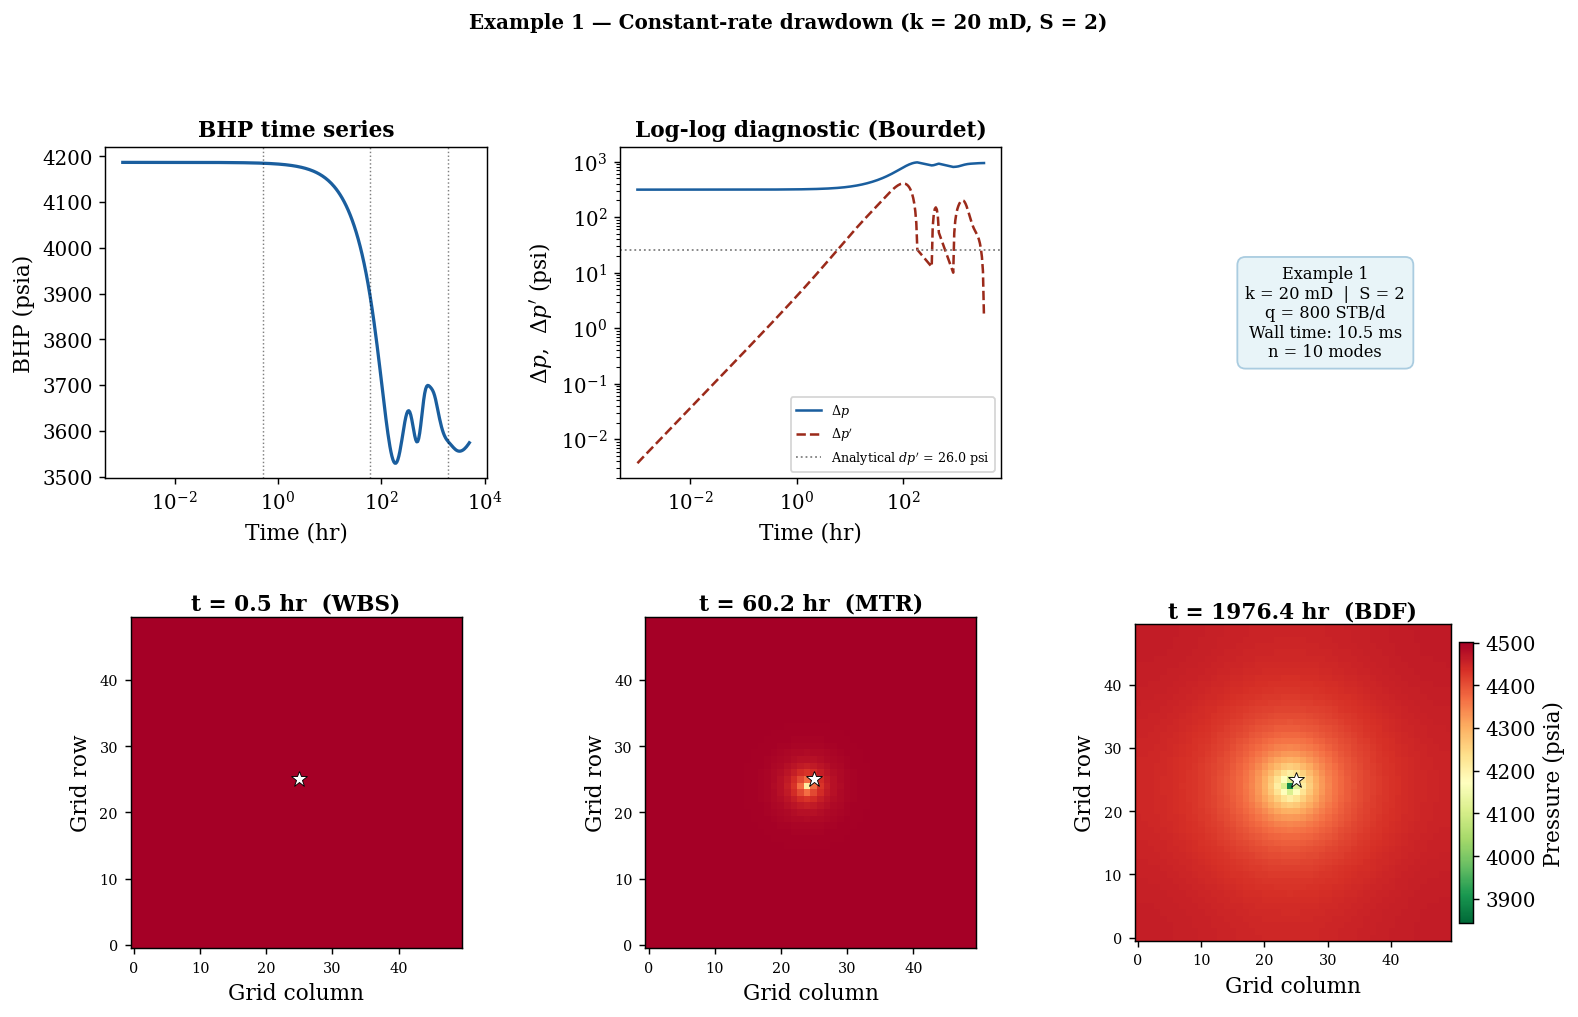

Figure saved.


In [11]:
r1 = predict(k_star=20, s_star=2, rate_schedule=[(0, 800)])
print(f'Wall time  : {r1["wall_ms"]:.1f} ms  |  Stabilised: {r1["stabilised"]}')
print(f'BHP range  : {r1["bhp_psia"].min():.1f} - {r1["bhp_psia"].max():.1f} psia')
print(f'Max dp     : {r1["dp_psi"].max():.1f} psi')

dp1_pos = np.clip(r1['dp_psi'], 1e-3, None)
t1, dp1_brd, bd1 = bourdet_derivative(r1['t_hr'], dp1_pos)

snap_wbs = np.argmin(np.abs(r1['t_hr'] - 0.5))
snap_mtr = np.argmin(np.abs(r1['t_hr'] - 60))
snap_bdf = np.argmin(np.abs(r1['t_hr'] - 2000))
snaps1   = [(snap_wbs, 'WBS'), (snap_mtr, 'MTR'), (snap_bdf, 'BDF')]
p_min1   = r1['p_field'].min()
p_max1   = r1['p_field'].max()

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax_bhp = fig.add_subplot(gs[0, 0])
ax_bhp.semilogx(r1['t_hr'], r1['bhp_psia'], lw=1.8, color=C1)
for s_idx, _ in snaps1:
    ax_bhp.axvline(r1['t_hr'][s_idx], color='k', ls=':', lw=0.8, alpha=0.5)
ax_bhp.set_xlabel('Time (hr)'); ax_bhp.set_ylabel('BHP (psia)')
ax_bhp.set_title('BHP time series')

ax_ll = fig.add_subplot(gs[0, 1])
if len(bd1) > 2:
    ax_ll.loglog(t1, dp1_brd, lw=1.4, color=C1,  label=r'$\Delta p$')
    ax_ll.loglog(t1, bd1,     lw=1.4, color=C3,  ls='--', label=r"$\Delta p'$")
dp_prime_an = 70.6 * 800 * MU_CP * BO / (20 * H_FT)
ax_ll.axhline(dp_prime_an, color='gray', ls=':', lw=1,
              label=f"Analytical $dp'$ = {dp_prime_an:.1f} psi")
ax_ll.set_xlabel('Time (hr)'); ax_ll.set_ylabel("$\\Delta p$,  $\\Delta p'$ (psi)")
ax_ll.set_title('Log-log diagnostic (Bourdet)'); ax_ll.legend(fontsize=7)

for col, (s_idx, s_lbl) in enumerate(snaps1):
    ax_m = fig.add_subplot(gs[1, col])
    im   = pressure_map_panel(ax_m, r1['p_field'], s_idx,
                               r1['t_hr'], p_min1, p_max1, s_lbl)
    if col == 2:
        plt.colorbar(im, ax=ax_m, label='Pressure (psia)', shrink=0.85, pad=0.02)

ax_info = fig.add_subplot(gs[0, 2]); ax_info.axis('off')
ax_info.text(0.5, 0.5,
    f'Example 1\nk = 20 mD  |  S = 2\nq = 800 STB/d\n'
    f'Wall time: {r1["wall_ms"]:.1f} ms\nn = {n} modes',
    ha='center', va='center', fontsize=9,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#e8f4f8', edgecolor='#aacce0'))

fig.suptitle('Example 1 — Constant-rate drawdown (k = 20 mD, S = 2)',
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig(RESULTS_DIR / 'example1_constant_rate.png', dpi=150, bbox_inches='tight')
plt.show(); print('Figure saved.')

## 3. Example 2 — Multi-step rate schedule

**k = 75 mD, S = 3** (off-grid — interpolated).

Three-period: high rate → reduced rate → shut-in buildup.

Wall time  : 6.0 ms  |  Stabilised: True
BHP range  : 4390.4 - 5656.9 psia


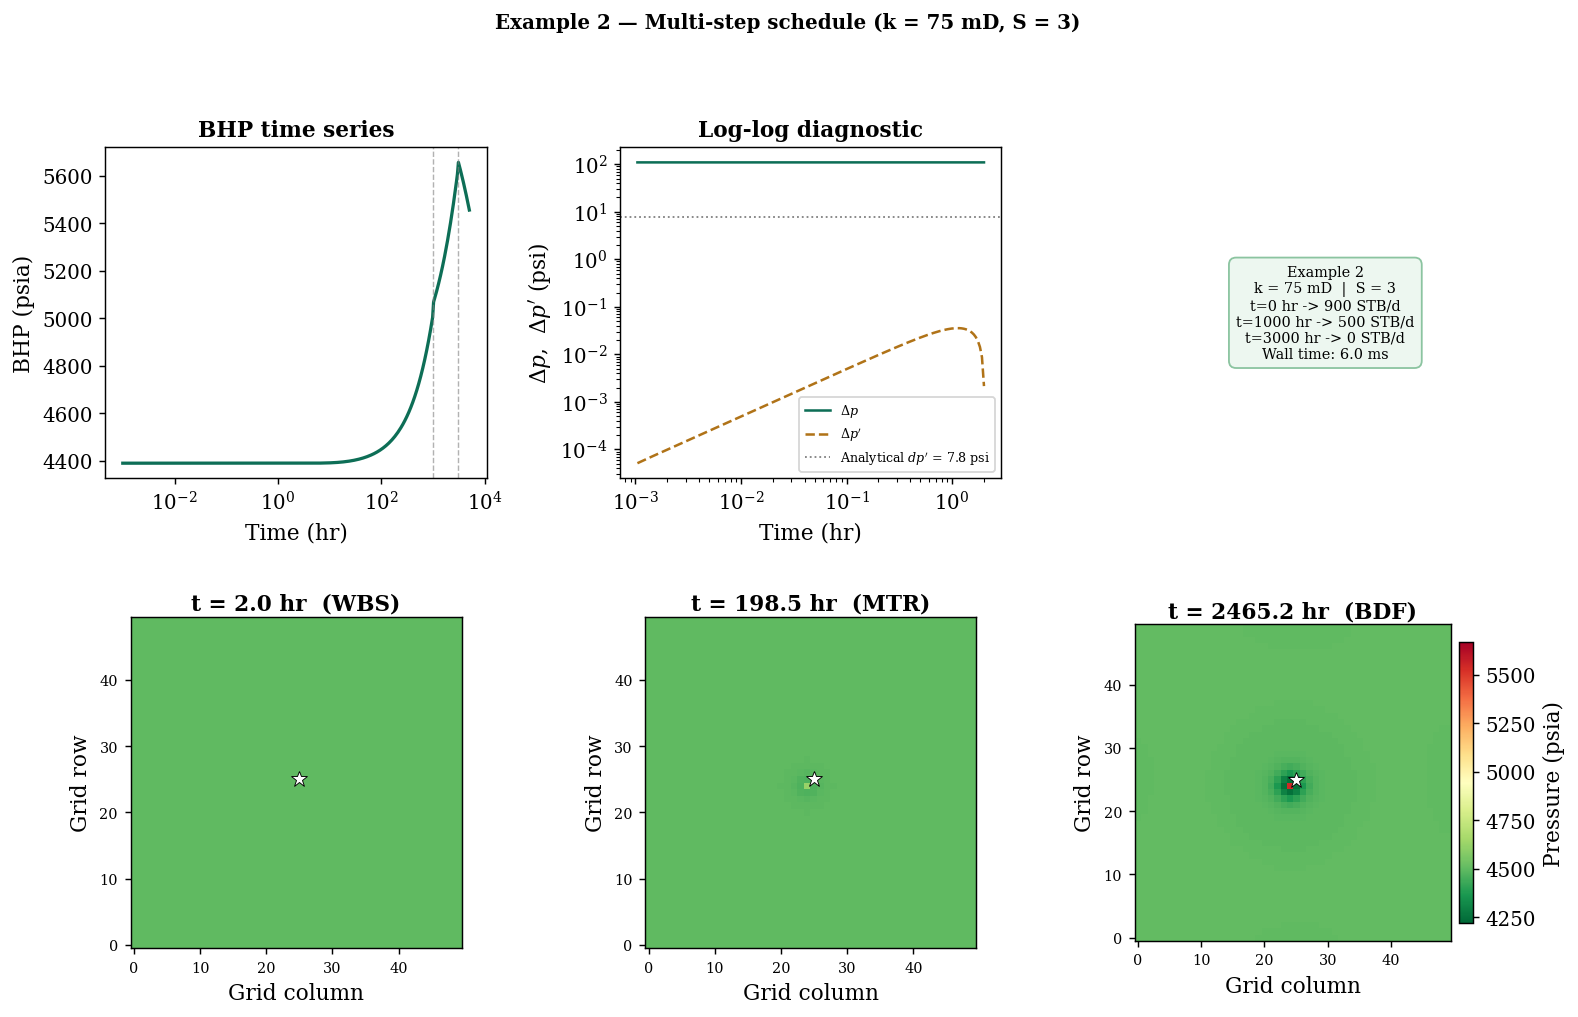

Figure saved.


In [12]:
k_query      = 75
S_query      = 3
rate_schedule = [
    (0,    900),
    (1000, 500),
    (3000,   0),
]

r2 = predict(k_star=k_query, s_star=S_query, rate_schedule=rate_schedule)
print(f'Wall time  : {r2["wall_ms"]:.1f} ms  |  Stabilised: {r2["stabilised"]}')
print(f'BHP range  : {r2["bhp_psia"].min():.1f} - {r2["bhp_psia"].max():.1f} psia')

dp2_pos = np.clip(r2['dp_psi'], 1e-3, None)
t2, dp2_brd, bd2 = bourdet_derivative(r2['t_hr'], dp2_pos)

snap2_wbs = np.argmin(np.abs(r2['t_hr'] - 2))
snap2_mtr = np.argmin(np.abs(r2['t_hr'] - 200))
snap2_bdf = np.argmin(np.abs(r2['t_hr'] - 2500))
snaps2    = [(snap2_wbs,'WBS'), (snap2_mtr,'MTR'), (snap2_bdf,'BDF')]
p_min2    = r2['p_field'].min()
p_max2    = r2['p_field'].max()

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax_bhp2 = fig.add_subplot(gs[0, 0])
ax_bhp2.semilogx(r2['t_hr'], r2['bhp_psia'], lw=1.8, color=C2)
for t_c, _ in rate_schedule[1:]:
    ax_bhp2.axvline(t_c, color='gray', ls='--', lw=0.8, alpha=0.6)
ax_bhp2.set_xlabel('Time (hr)'); ax_bhp2.set_ylabel('BHP (psia)')
ax_bhp2.set_title('BHP time series')

ax_ll2 = fig.add_subplot(gs[0, 1])
if len(bd2) > 2:
    ax_ll2.loglog(t2, dp2_brd, lw=1.4, color=C2, label=r'$\Delta p$')
    ax_ll2.loglog(t2, bd2,     lw=1.4, color=C4, ls='--', label=r"$\Delta p'$")
dp_prime_an2 = 70.6 * 900 * MU_CP * BO / (k_query * H_FT)
ax_ll2.axhline(dp_prime_an2, color='gray', ls=':', lw=1,
               label=f"Analytical $dp'$ = {dp_prime_an2:.1f} psi")
ax_ll2.set_xlabel('Time (hr)'); ax_ll2.set_ylabel("$\\Delta p$,  $\\Delta p'$ (psi)")
ax_ll2.set_title('Log-log diagnostic'); ax_ll2.legend(fontsize=7)

for col, (s_idx, s_lbl) in enumerate(snaps2):
    ax_m = fig.add_subplot(gs[1, col])
    im   = pressure_map_panel(ax_m, r2['p_field'], s_idx,
                               r2['t_hr'], p_min2, p_max2, s_lbl)
    if col == 2:
        plt.colorbar(im, ax=ax_m, label='Pressure (psia)', shrink=0.85, pad=0.02)

ax_info2 = fig.add_subplot(gs[0, 2]); ax_info2.axis('off')
sched_txt = '\n'.join([f't={tc} hr -> {rv} STB/d' for tc, rv in rate_schedule])
ax_info2.text(0.5, 0.5,
    f'Example 2\nk = {k_query} mD  |  S = {S_query}\n{sched_txt}\n'
    f'Wall time: {r2["wall_ms"]:.1f} ms',
    ha='center', va='center', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#edf7f0', edgecolor='#8bc4a0'))

fig.suptitle(f'Example 2 — Multi-step schedule (k = {k_query} mD, S = {S_query})',
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig(RESULTS_DIR / 'example2_multistep.png', dpi=150, bbox_inches='tight')
plt.show(); print('Figure saved.')

## 4. Example 3 — Low-permeability, high-skin case

**k = 10 mD, S = 10** — tight reservoir with significant skin damage.

Expected: long WBS, large MTR slope, steep pressure cone near well.

Wall time  : 6.0 ms  |  Stabilised: True
BHP range  : 3384.7 - 13006.2 psia


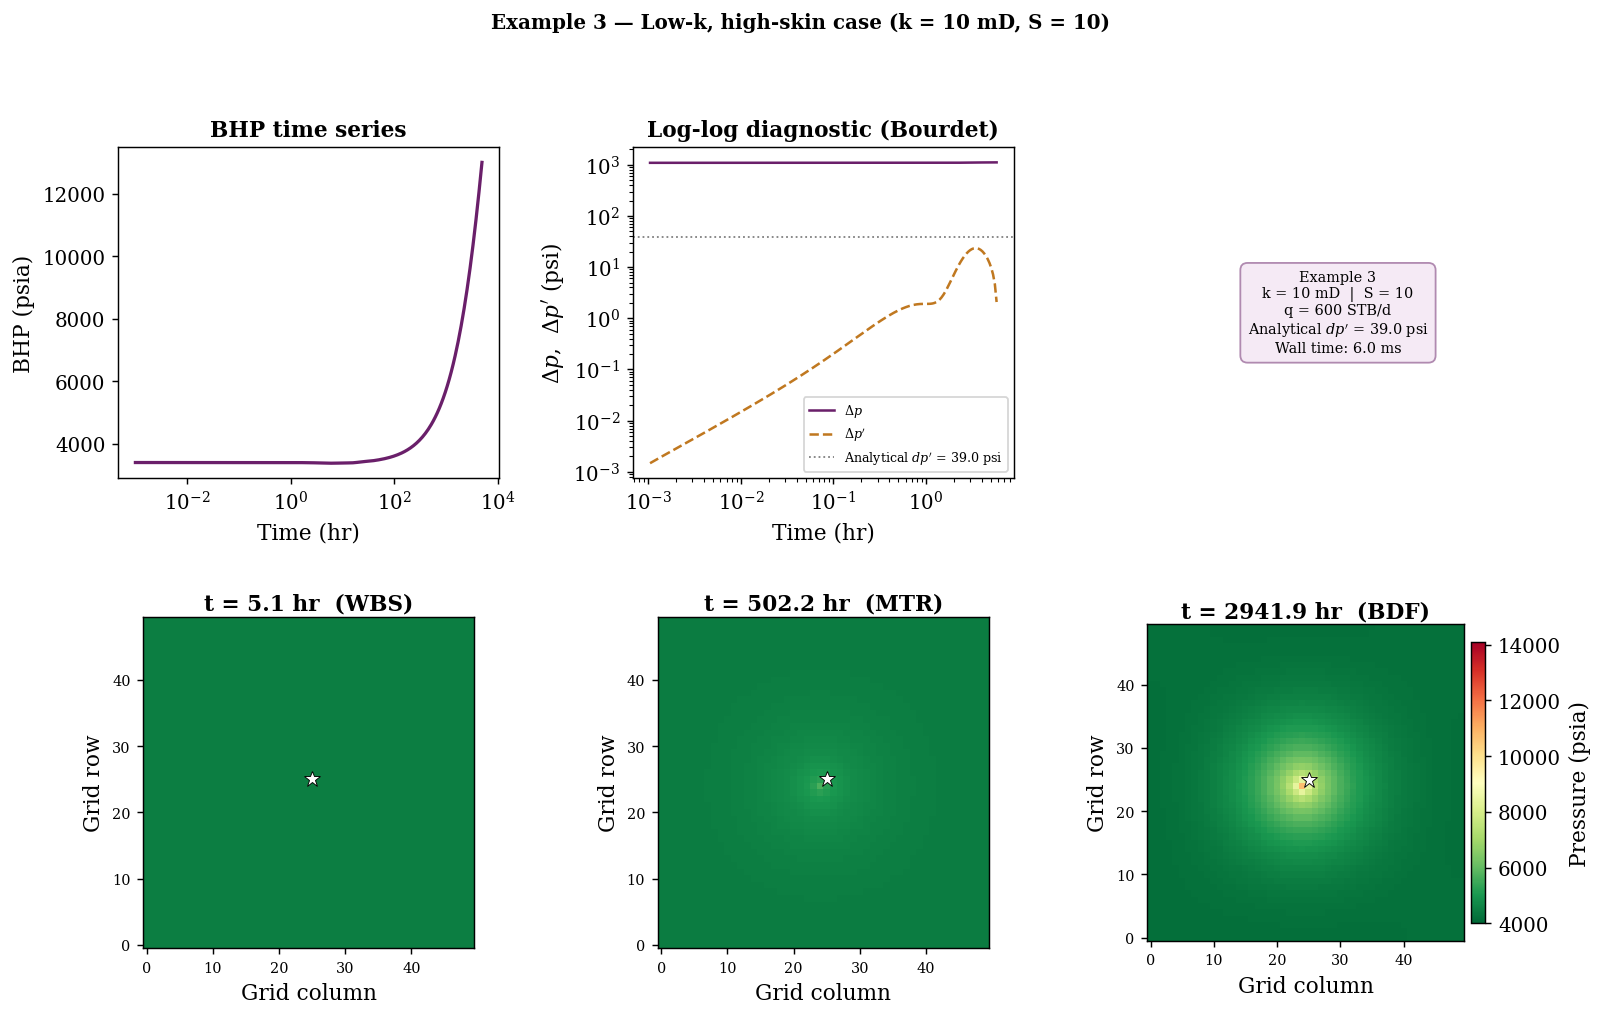

Figure saved.


In [13]:
r3 = predict(k_star=10, s_star=10, rate_schedule=[(0, 600)])
print(f'Wall time  : {r3["wall_ms"]:.1f} ms  |  Stabilised: {r3["stabilised"]}')
print(f'BHP range  : {r3["bhp_psia"].min():.1f} - {r3["bhp_psia"].max():.1f} psia')

dp3_pos = np.clip(r3['dp_psi'], 1e-3, None)
t3, dp3_brd, bd3 = bourdet_derivative(r3['t_hr'], dp3_pos)
dp_prime_ex3 = 70.6 * 600 * MU_CP * BO / (10 * H_FT)

snap3_wbs = np.argmin(np.abs(r3['t_hr'] - 5))
snap3_mtr = np.argmin(np.abs(r3['t_hr'] - 500))
snap3_bdf = np.argmin(np.abs(r3['t_hr'] - 3000))
snaps3    = [(snap3_wbs,'WBS'), (snap3_mtr,'MTR'), (snap3_bdf,'BDF')]
p_min3    = r3['p_field'].min(); p_max3 = r3['p_field'].max()

fig = plt.figure(figsize=(14, 8))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.42, wspace=0.35)

ax_bhp3 = fig.add_subplot(gs[0, 0])
ax_bhp3.semilogx(r3['t_hr'], r3['bhp_psia'], lw=1.8, color='#6a1f6a')
ax_bhp3.set_xlabel('Time (hr)'); ax_bhp3.set_ylabel('BHP (psia)')
ax_bhp3.set_title('BHP time series')

ax_ll3 = fig.add_subplot(gs[0, 1])
if len(bd3) > 2:
    ax_ll3.loglog(t3, dp3_brd, lw=1.4, color='#6a1f6a',  label=r'$\Delta p$')
    ax_ll3.loglog(t3, bd3,     lw=1.4, color='#c07820',  ls='--', label=r"$\Delta p'$")
ax_ll3.axhline(dp_prime_ex3, color='gray', ls=':', lw=1,
               label=f"Analytical $dp'$ = {dp_prime_ex3:.1f} psi")
ax_ll3.set_xlabel('Time (hr)'); ax_ll3.set_ylabel("$\\Delta p$,  $\\Delta p'$ (psi)")
ax_ll3.set_title('Log-log diagnostic (Bourdet)'); ax_ll3.legend(fontsize=7)

for col, (s_idx, s_lbl) in enumerate(snaps3):
    ax_m = fig.add_subplot(gs[1, col])
    im   = pressure_map_panel(ax_m, r3['p_field'], s_idx,
                               r3['t_hr'], p_min3, p_max3, s_lbl)
    if col == 2:
        plt.colorbar(im, ax=ax_m, label='Pressure (psia)', shrink=0.85, pad=0.02)

ax_info3 = fig.add_subplot(gs[0, 2]); ax_info3.axis('off')
ax_info3.text(0.5, 0.5,
    f'Example 3\nk = 10 mD  |  S = 10\nq = 600 STB/d\n'
    f"Analytical $dp'$ = {dp_prime_ex3:.1f} psi\n"
    f'Wall time: {r3["wall_ms"]:.1f} ms',
    ha='center', va='center', fontsize=8,
    bbox=dict(boxstyle='round,pad=0.5', facecolor='#f5eaf5', edgecolor='#b08ab0'))

fig.suptitle('Example 3 — Low-k, high-skin case (k = 10 mD, S = 10)',
             fontsize=11, fontweight='bold', y=1.01)
plt.savefig(RESULTS_DIR / 'example3_low_k_high_skin.png', dpi=150, bbox_inches='tight')
plt.show(); print('Figure saved.')

## 5. Parametric sweep — effect of permeability

Seven k values at fixed S = 5, constant 800 STB/d.

**Correctness check:** Bourdet flat level must satisfy $dp' \propto 1/k$.

7 predictions in 45 ms  (6.5 ms each)


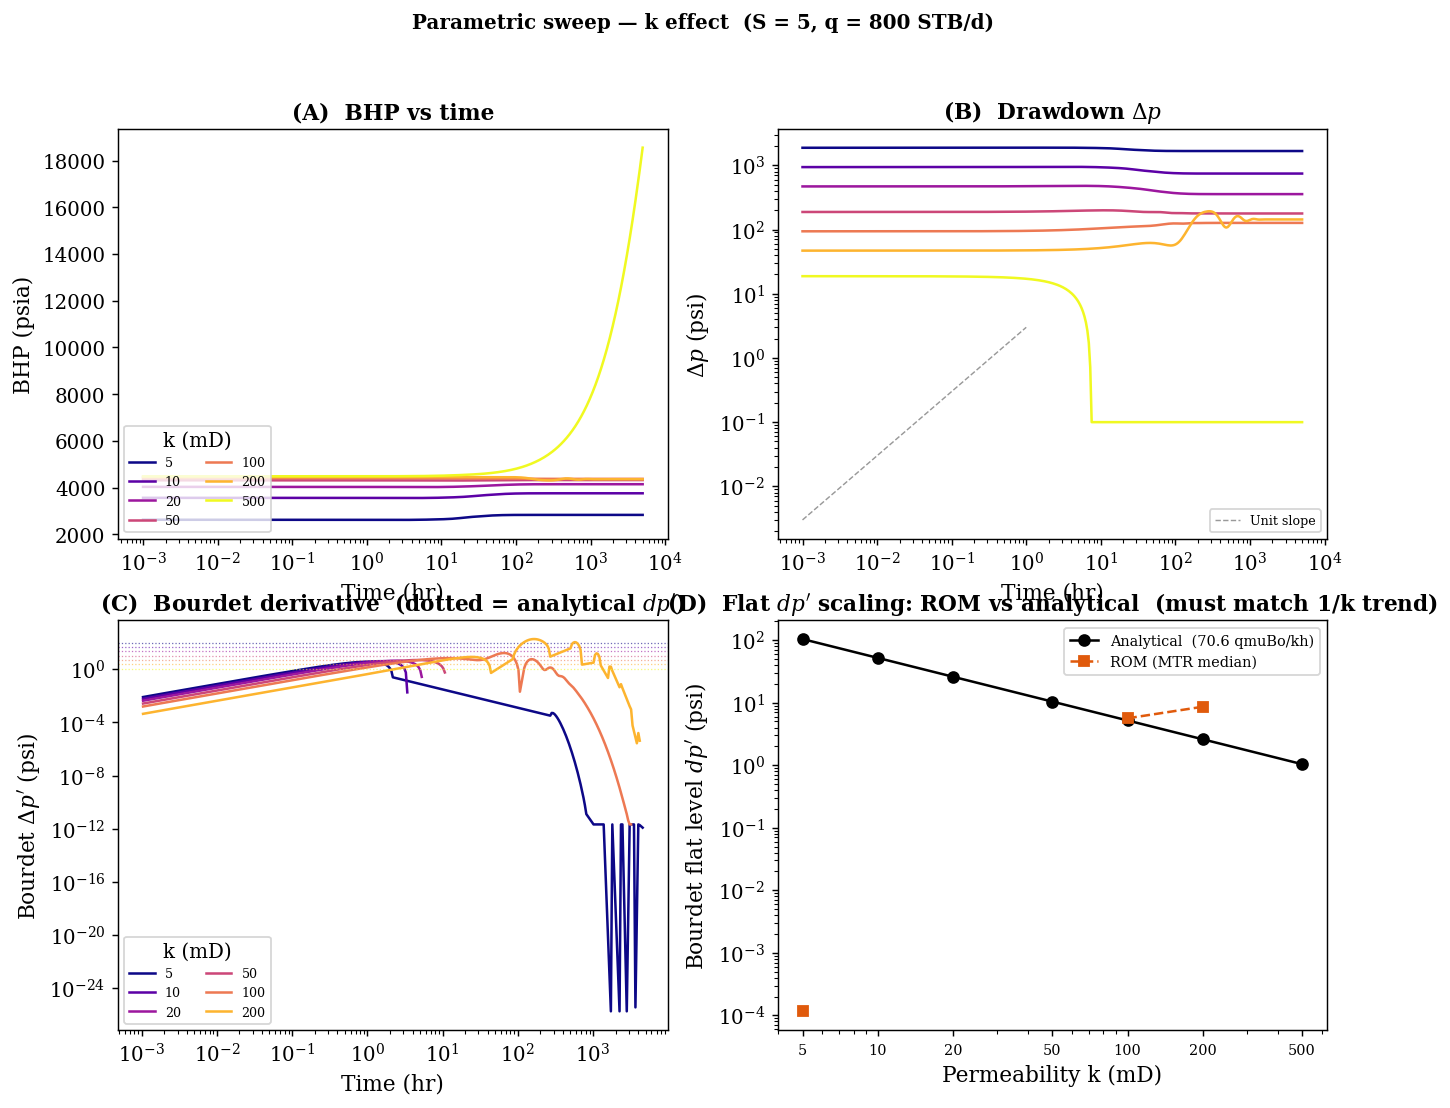

Figure saved.


In [14]:
k_sweep  = [5, 10, 20, 50, 100, 200, 500]
S_fixed  = 5
q_const  = [(0, 800)]

cmap_sweep = plt.cm.plasma
colors_k   = [cmap_sweep(i / (len(k_sweep) - 1)) for i in range(len(k_sweep))]

sweep_results = {}
t_start_sw = time.perf_counter()
for k_v in k_sweep:
    sweep_results[k_v] = predict(k_v, S_fixed, q_const)
total_ms = (time.perf_counter() - t_start_sw) * 1000
print(f'{len(k_sweep)} predictions in {total_ms:.0f} ms  ({total_ms/len(k_sweep):.1f} ms each)')

fig, axes = plt.subplots(2, 2, figsize=(12, 9))

ax_A = axes[0, 0]
for k_v, col in zip(k_sweep, colors_k):
    res = sweep_results[k_v]
    ax_A.semilogx(res['t_hr'], res['bhp_psia'], lw=1.4, color=col, label=f'{k_v}')
ax_A.set_xlabel('Time (hr)'); ax_A.set_ylabel('BHP (psia)')
ax_A.set_title('(A)  BHP vs time')
ax_A.legend(title='k (mD)', fontsize=7, ncol=2, loc='lower left', framealpha=0.8)

ax_B = axes[0, 1]
for k_v, col in zip(k_sweep, colors_k):
    res    = sweep_results[k_v]
    dp_plot = np.clip(res['dp_psi'], 0.1, None)
    ax_B.loglog(res['t_hr'], dp_plot, lw=1.4, color=col)
t_ref = np.array([0.001, 1])
ax_B.loglog(t_ref, t_ref * 3, 'k--', lw=0.8, alpha=0.4, label='Unit slope')
ax_B.set_xlabel('Time (hr)'); ax_B.set_ylabel(r'$\Delta p$ (psi)')
ax_B.set_title(r'(B)  Drawdown $\Delta p$'); ax_B.legend(fontsize=7)

ax_C = axes[1, 0]
dp_rom_flat = []
for k_v, col in zip(k_sweep, colors_k):
    res  = sweep_results[k_v]
    dp_c = np.clip(res['dp_psi'], 0.1, None)
    tc, dpc, bdc = bourdet_derivative(res['t_hr'], dp_c)
    if len(bdc) > 3:
        ax_C.loglog(tc, bdc, lw=1.4, color=col, label=f'{k_v}')
    dp_an = 70.6 * 800 * MU_CP * BO / (k_v * H_FT)
    ax_C.axhline(dp_an, color=col, ls=':', lw=0.7, alpha=0.6)
    mtr_m = (tc >= 10) & (tc <= 500)
    dp_rom_flat.append(float(np.median(bdc[mtr_m])) if (len(bdc)>3 and mtr_m.sum()>3) else np.nan)
ax_C.set_xlabel('Time (hr)'); ax_C.set_ylabel(r"Bourdet $\Delta p'$ (psi)")
ax_C.set_title(r"(C)  Bourdet derivative  (dotted = analytical $dp'$)")
ax_C.legend(title='k (mD)', fontsize=7, ncol=2, framealpha=0.8)

ax_D = axes[1, 1]
dp_analytical = [70.6 * 800 * MU_CP * BO / (k_v * H_FT) for k_v in k_sweep]
ax_D.loglog(k_sweep, dp_analytical, 'k-o', lw=1.4, ms=6,
            label='Analytical  (70.6 qmuBo/kh)')
ax_D.loglog(k_sweep, dp_rom_flat,   's--', lw=1.4, ms=6,
            color='#e05a0c', label='ROM (MTR median)')
ax_D.set_xlabel('Permeability k (mD)'); ax_D.set_ylabel(r"Bourdet flat level $dp'$ (psi)")
ax_D.set_title(r"(D)  Flat $dp'$ scaling: ROM vs analytical  (must match 1/k trend)")
ax_D.legend(fontsize=8); ax_D.set_xticks(k_sweep); ax_D.set_xticklabels(k_sweep, fontsize=8)

fig.suptitle(f'Parametric sweep — k effect  (S = {S_fixed}, q = 800 STB/d)',
             fontsize=11, fontweight='bold')
plt.savefig(RESULTS_DIR / 'parametric_sweep_k.png', dpi=150, bbox_inches='tight')
plt.show(); print('Figure saved.')

## 6. Parametric sweep — effect of skin

Six S values at fixed k = 50 mD, constant 800 STB/d.

**Correctness check:** Bourdet flat level must be **independent of S** — skin shifts BHP but not $dp'$.

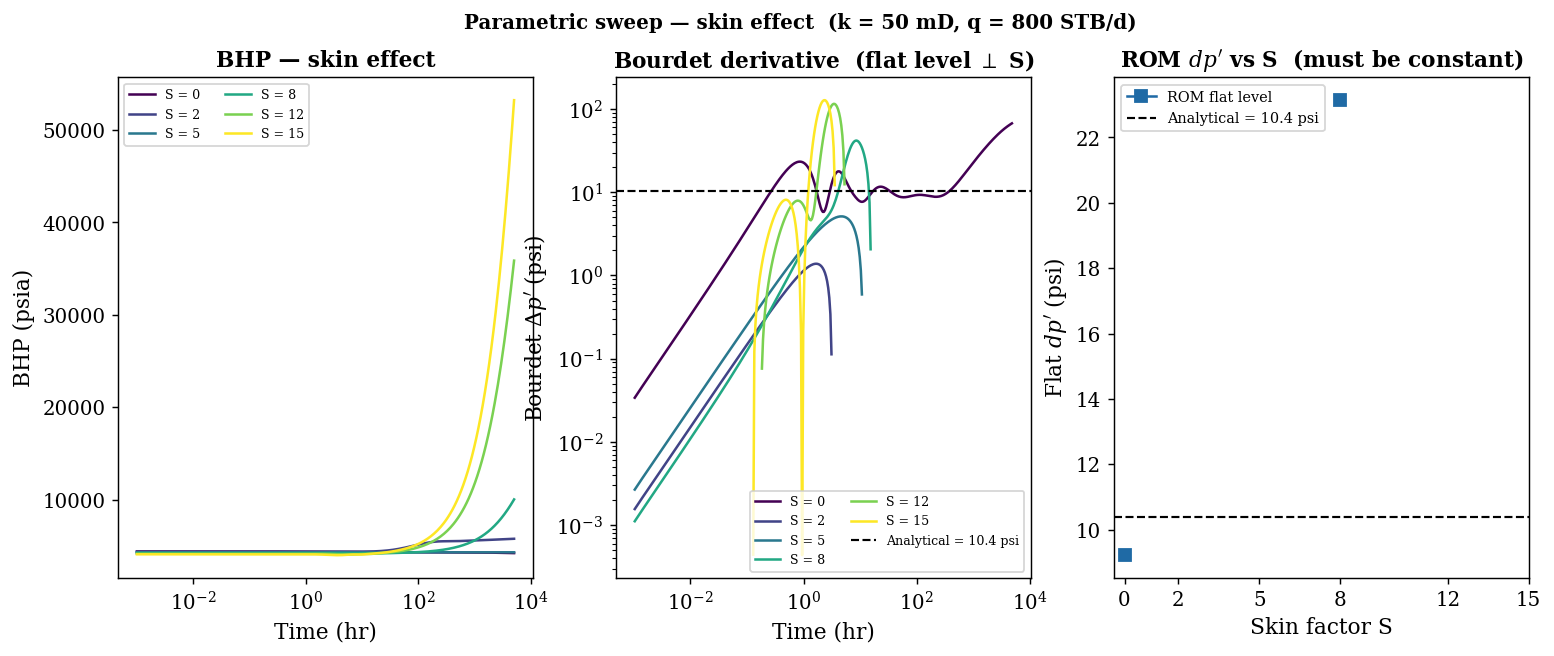

Figure saved.


In [15]:
S_sweep  = [0, 2, 5, 8, 12, 15]
k_fixed  = 50

cmap_s   = plt.cm.viridis
colors_s = [cmap_s(i / (len(S_sweep) - 1)) for i in range(len(S_sweep))]

sweep_s = {}
for s_v in S_sweep:
    sweep_s[s_v] = predict(k_fixed, s_v, [(0, 800)])

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

for s_v, col in zip(S_sweep, colors_s):
    res = sweep_s[s_v]
    axes[0].semilogx(res['t_hr'], res['bhp_psia'], lw=1.4,
                     color=col, label=f'S = {s_v}')
axes[0].set_xlabel('Time (hr)'); axes[0].set_ylabel('BHP (psia)')
axes[0].set_title('BHP — skin effect'); axes[0].legend(fontsize=7, ncol=2)

dp_flat_s = []
for s_v, col in zip(S_sweep, colors_s):
    res  = sweep_s[s_v]
    dp_c = np.clip(res['dp_psi'], 0.1, None)
    ts, dps, bds = bourdet_derivative(res['t_hr'], dp_c)
    if len(bds) > 3:
        axes[1].loglog(ts, bds, lw=1.4, color=col, label=f'S = {s_v}')
    mtr_m = (ts >= 10) & (ts <= 500)
    dp_flat_s.append(float(np.median(bds[mtr_m])) if (len(bds)>3 and mtr_m.sum()>3) else np.nan)

dp_prime_k50 = 70.6 * 800 * MU_CP * BO / (k_fixed * H_FT)
axes[1].axhline(dp_prime_k50, color='k', ls='--', lw=1.2,
                label=f"Analytical = {dp_prime_k50:.1f} psi")
axes[1].set_xlabel('Time (hr)'); axes[1].set_ylabel(r"Bourdet $\Delta p'$ (psi)")
axes[1].set_title(r"Bourdet derivative  (flat level $\perp$ S)")
axes[1].legend(fontsize=7, ncol=2)

axes[2].plot(S_sweep, dp_flat_s, 's-', color='#1f6aa5', ms=7, lw=1.4,
             label='ROM flat level')
axes[2].axhline(dp_prime_k50, color='k', ls='--', lw=1.2,
                label=f'Analytical = {dp_prime_k50:.1f} psi')
axes[2].set_xlabel('Skin factor S'); axes[2].set_ylabel(r"Flat $dp'$ (psi)")
axes[2].set_title(r"ROM $dp'$ vs S  (must be constant)")
axes[2].legend(fontsize=8); axes[2].set_xticks(S_sweep)

fig.suptitle(f'Parametric sweep — skin effect  (k = {k_fixed} mD, q = 800 STB/d)',
             fontsize=11, fontweight='bold')
plt.savefig(RESULTS_DIR / 'parametric_sweep_S.png', dpi=150, bbox_inches='tight')
plt.show(); print('Figure saved.')

## 7. Save prediction results

In [16]:
timestamp = datetime.datetime.now().strftime('%Y%m%d_%H%M%S')
pred_name = f'k{k_query:03d}_s{S_query:02d}_{timestamp}'
pred_dir  = RESULTS_DIR / pred_name
pred_dir.mkdir(parents=True, exist_ok=True)

np.save(pred_dir / 't_hr.npy',     r2['t_hr'])
np.save(pred_dir / 'bhp_psia.npy', r2['bhp_psia'])
np.save(pred_dir / 'dp_psi.npy',   r2['dp_psi'])
np.save(pred_dir / 'p_field.npy',  r2['p_field'])
np.save(pred_dir / 'q_vec.npy',    r2['q_vec'])

query_log = dict(
    timestamp     = timestamp,
    k_mD          = k_query,
    S_skin        = S_query,
    rate_schedule = rate_schedule,
    stable        = r2['stable'],
    stabilised    = r2['stabilised'],
    wall_ms       = r2['wall_ms'],
    n_modes       = int(n),
    bhp_min_psia  = float(r2['bhp_psia'].min()),
    bhp_max_psia  = float(r2['bhp_psia'].max()),
    wc_idx        = WC_IDX,
    r_eq_ft       = R_EQ_FT,
    rw_ft         = RW_FT,
)
with open(pred_dir / 'query_log.json', 'w') as f:
    json.dump(query_log, f, indent=2)

print(f'Saved to : {pred_dir}')
print(f't_hr     : {r2["t_hr"].shape}')
print(f'bhp_psia : {r2["bhp_psia"].shape}')
print(f'p_field  : {r2["p_field"].shape}')
print(f'wall time: {r2["wall_ms"]:.1f} ms')

Saved to : ..\results\predictions\k075_s03_20260428_191325
t_hr     : (350,)
bhp_psia : (350,)
p_field  : (2500, 350)
wall time: 6.0 ms
